In [1]:
# ============================================================
# modelling.ipynb
# ELE8101 CW2 — Member A: ChenhuiCui
# Tasks: A1 Track Geometry, A2 Vehicle Motion Model,
#        A3 Beacon Optimisation, A4 Noise Analysis, A5 Sensor Bias
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

np.random.seed(42)  # fix seed for reproducibility

In [2]:
# ============================================================
# A1: Track Geometry
# ============================================================
# The track has an asymmetric teardrop shape consisting of:
#   - Two circular arcs (large at A, small at B)
#   - Two straight sections (common external tangents)
# Vehicle travels clockwise.
#
# We parameterise the track using arc-length s (distance
# travelled along the centreline from the starting point)
# and lateral offset ell (perpendicular distance from
# centreline, positive toward outer wall).
#
# Reference: Problem statement Figure 1.
# ============================================================

# ── Parameters from problem statement ───────────────────────
R   = 50.0   # outer wall radius at A (m)
r   = 46.0   # inner wall radius at A (m)
rho = 20.0   # inner wall radius at B (m) — from Figure 1,
             # the arrow points from B centre to the inner wall
d   = 100.0  # distance between arc centres A and B (m)

# ── Derived centreline radii ─────────────────────────────────
# Centreline is halfway between inner and outer walls.
# At A: centreline radius = average of R and r
# At B: rho is inner wall radius, so centreline = rho + half-width
R_A = (R + r) / 2   # centreline radius at A = 48.0 m
w   = (R - r) / 2   # track half-width = 2.0 m
R_B = rho + w        # centreline radius at B = 22.0 m

# ── Common external tangent geometry ────────────────────────
# The two straight sections are common external tangents to
# the two circular arcs. Since R_A ≠ R_B, the straights are
# inclined at angle alpha to the horizontal.
#
# From the external tangent geometry:
#   sin(alpha) = (R_A - R_B) / d
#   l_tan      = sqrt(d² - (R_A - R_B)²)   [Pythagorean theorem]
alpha = np.arcsin((R_A - R_B) / d)
cos_a = np.cos(alpha)
sin_a = np.sin(alpha)

l_tan   = np.sqrt(d**2 - (R_A - R_B)**2)   # straight length (m)

# ── Arc lengths ──────────────────────────────────────────────
# Arc length = radius × central angle (radians)
# Large arc at A subtends angle (π + 2α): slightly more than semicircle
# Small arc at B subtends angle (π - 2α): slightly less than semicircle
#
# Derivation of central angles:
#   Upper tangent point seen from A: angle = π/2 + α
#   Lower tangent point seen from A: angle = -π/2 - α
#   Clockwise sweep from upper to lower = (π/2+α) - (-π/2-α) = π + 2α
l_arc_A = R_A * (np.pi + 2*alpha)   # large arc length (m)
l_arc_B = R_B * (np.pi - 2*alpha)   # small arc length (m)

# ── Total perimeter ──────────────────────────────────────────
L = 2*l_tan + l_arc_A + l_arc_B     # total track perimeter (m)

# ── Arc centres ─────────────────────────────────────────────
A_centre = np.array([0.0, 0.0])     # A at origin
B_centre = np.array([d,   0.0])     # B at (100, 0)

# ── Segment boundary arc-lengths ────────────────────────────
# The track is divided into 4 segments for arc-length computation.
# These boundaries are our own design choice to enable efficient
# piecewise computation. Each segment uses a different formula:
#   - Straight: line equation
#   - Arc: circle parametric equation
#
# Clockwise order:
#   Seg 1: upper straight  (A → B)     s ∈ [0,  s1]
#   Seg 2: small arc at B  (clockwise) s ∈ [s1, s2]
#   Seg 3: lower straight  (B → A)     s ∈ [s2, s3]
#   Seg 4: large arc at A  (clockwise) s ∈ [s3, L ]
s1 = l_tan             # end of upper straight
s2 = s1 + l_arc_B      # end of small arc
s3 = s2 + l_tan        # end of lower straight

print(f"Track parameters:")
print(f"  R_A = {R_A:.4f} m  (centreline radius at A)")
print(f"  R_B = {R_B:.4f} m  (centreline radius at B = rho + w)")
print(f"  w   = {w:.4f} m  (track half-width)")
print(f"  alpha = {np.degrees(alpha):.4f} deg  (straight inclination angle)")
print(f"  l_tan   = {l_tan:.4f} m  (straight length)")
print(f"  l_arc_A = {l_arc_A:.4f} m  (large arc length)")
print(f"  l_arc_B = {l_arc_B:.4f} m  (small arc length)")
print(f"  L = {L:.4f} m  (total perimeter)")
print(f"  One lap at 10 m/s: {L/10:.1f} s")
print(f"\nSegment boundaries:")
print(f"  s1 = {s1:.4f} m  (upper straight ends)")
print(f"  s2 = {s2:.4f} m  (small arc ends)")
print(f"  s3 = {s3:.4f} m  (lower straight ends)")
print(f"  L  = {L:.4f} m  (large arc ends, back to start)")

Track parameters:
  R_A = 48.0000 m  (centreline radius at A)
  R_B = 22.0000 m  (centreline radius at B = rho + w)
  w   = 2.0000 m  (track half-width)
  alpha = 15.0701 deg  (straight inclination angle)
  l_tan   = 96.5609 m  (straight length)
  l_arc_A = 176.0466 m  (large arc length)
  l_arc_B = 57.5421 m  (small arc length)
  L = 426.7104 m  (total perimeter)
  One lap at 10 m/s: 42.7 s

Segment boundaries:
  s1 = 96.5609 m  (upper straight ends)
  s2 = 154.1029 m  (small arc ends)
  s3 = 250.6638 m  (lower straight ends)
  L  = 426.7104 m  (large arc ends, back to start)


In [3]:
# ============================================================
# A1: Three core geometry functions
# ============================================================

def s_to_xy(s):
    """
    Map arc-length s to Cartesian coordinates (x, y)
    on the track centreline.

    The track is divided into 4 segments (clockwise order):
      Seg 1: upper straight  A → B
      Seg 2: small arc at B  (clockwise)
      Seg 3: lower straight  B → A
      Seg 4: large arc at A  (clockwise)

    Parameters
    ----------
    s : float
        Arc-length along the centreline (m). Any value is valid;
        s % L handles multiple laps.

    Returns
    -------
    np.array, shape (2,)
        Cartesian coordinates (x, y) on the centreline.
    """
    s = s % L   # handle multiple laps: s modulo L

    if s < s1:
        # ── Seg 1: upper straight ────────────────────────────
        # Starting point A_top: tangent point where upper straight
        # meets large arc at A. Computed by moving R_A metres from
        # A centre in the outward normal direction [sin_a, cos_a].
        A_top = A_centre + R_A * np.array([sin_a, cos_a])
        # Travel direction of upper straight: (cos_a, -sin_a)
        # (rightward and slightly downward for clockwise travel)
        return A_top + s * np.array([cos_a, -sin_a])

    elif s < s2:
        # ── Seg 2: small arc at B ────────────────────────────
        # Clockwise rotation: angle decreases as s increases.
        # Starting angle: (π/2 - alpha) = angle of upper tangent
        # point as seen from B centre.
        # Angle change: (s - s1) / R_B   [arc = radius × angle]
        theta = (np.pi/2 - alpha) - (s - s1) / R_B
        # Circle parametric equation: centre + radius × (cos, sin)
        return B_centre + R_B * np.array([np.cos(theta), np.sin(theta)])

    elif s < s3:
        # ── Seg 3: lower straight ────────────────────────────
        # Starting point B_bot: tangent point where lower straight
        # meets small arc at B.
        B_bot = B_centre + R_B * np.array([sin_a, -cos_a])
        # Travel direction: (-cos_a, -sin_a)
        # (leftward and slightly downward for clockwise travel)
        return B_bot + (s - s2) * np.array([-cos_a, -sin_a])

    else:
        # ── Seg 4: large arc at A ────────────────────────────
        # Starting angle: (-π/2 + alpha) = angle of lower tangent
        # point as seen from A centre.
        # Clockwise: angle decreases as s increases.
        theta = (-np.pi/2 + alpha) - (s - s3) / R_A
        return A_centre + R_A * np.array([np.cos(theta), np.sin(theta)])


def s_to_normal(s):
    """
    Return the unit outward normal vector at arc-length s.

    The normal vector is perpendicular to the track direction
    and points outward (toward the outer wall).
    - On straight sections: constant (straight has no curvature)
    - On arc sections: rotates with position, always pointing
      radially outward from the arc centre

    This vector is needed to convert lateral offset ell into
    a spatial displacement: position = centreline + ell × normal.

    Parameters
    ----------
    s : float
        Arc-length along the centreline (m).

    Returns
    -------
    np.array, shape (2,)
        Unit outward normal vector (|n| = 1).
    """
    s = s % L

    if s < s1:
        # Upper straight: constant outward normal [sin_a, cos_a]
        # (perpendicular to travel direction [cos_a, -sin_a],
        #  pointing upward-left = outward for upper straight)
        return np.array([sin_a, cos_a])

    elif s < s2:
        # Small arc at B: normal = radial direction from B centre
        # (same angle theta as s_to_xy for this segment)
        theta = (np.pi/2 - alpha) - (s - s1) / R_B
        return np.array([np.cos(theta), np.sin(theta)])

    elif s < s3:
        # Lower straight: constant outward normal [sin_a, -cos_a]
        # (pointing downward-right = outward for lower straight)
        return np.array([sin_a, -cos_a])

    else:
        # Large arc at A: normal = radial direction from A centre
        theta = (-np.pi/2 + alpha) - (s - s3) / R_A
        return np.array([np.cos(theta), np.sin(theta)])


def sl_to_xy(s, ell):
    """
    Map (arc-length s, lateral offset ell) to Cartesian (x, y).

    The true vehicle position is the centreline point displaced
    by ell metres in the outward normal direction:

        position = s_to_xy(s) + ell * s_to_normal(s)

    Parameters
    ----------
    s   : float  Arc-length (m)
    ell : float  Lateral offset (m)
                 ell =  0 : on centreline
                 ell = +2 : at outer wall
                 ell = -2 : at inner wall

    Returns
    -------
    np.array, shape (2,)
        Cartesian coordinates (x, y) of the vehicle.
    """
    return s_to_xy(s) + ell * s_to_normal(s)

Check 1: Track width (should all be 4.0000 m)
  s=  0.000: width = 4.0000 m
  s= 48.280: width = 4.0000 m
  s= 96.561: width = 4.0000 m
  s=154.103: width = 4.0000 m
  s=202.383: width = 4.0000 m
  s=250.664: width = 4.0000 m
  s=294.675: width = 4.0000 m

Check 2: Normal vector lengths (should all be 1.000000)
  s=  0.000: |n| = 1.000000
  s= 48.280: |n| = 1.000000
  s= 96.561: |n| = 1.000000
  s=154.103: |n| = 1.000000
  s=250.664: |n| = 1.000000

Check 3: Continuity at boundaries (gap should be ~0 mm)
  s=96.561 (upper straight → small arc): gap = 2.00 mm
  s=154.103 (small arc → lower straight): gap = 2.00 mm
  s=250.664 (lower straight → large arc): gap = 2.00 mm
  s=426.710 (large arc → upper straight (wrap)): gap = 2.00 mm

Check 4: Direction at s=0 (x should increase → clockwise)
  s=0: (12.48, 46.35)
  s=5: (17.31, 45.05)
  Δx = 4.83 (positive = rightward = clockwise ✓)


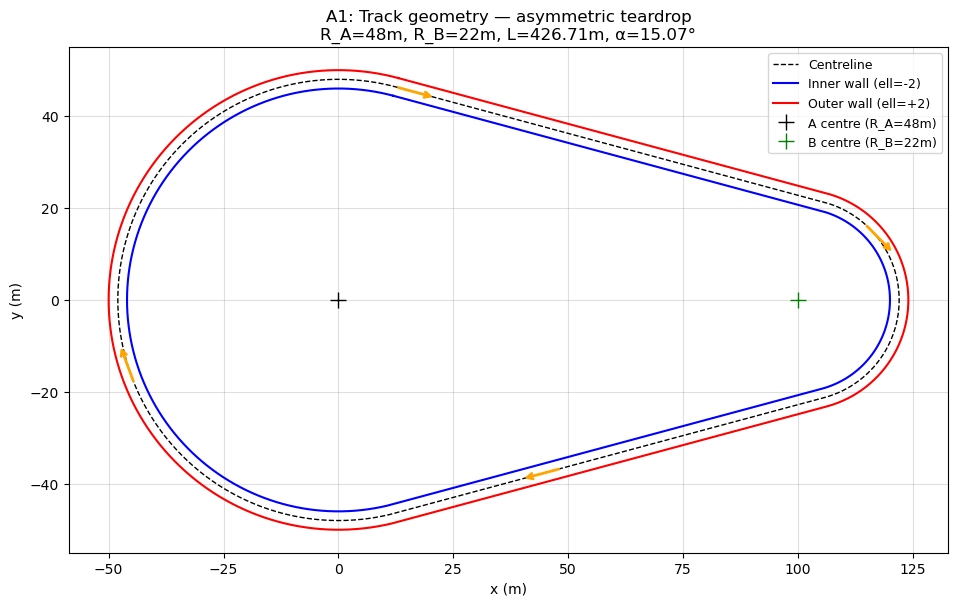


A1 complete. Track perimeter L = 426.7104 m
One lap at 10 m/s takes 42.7 s


In [4]:
# ============================================================
# A1: Verification
# ============================================================
# We verify three properties:
#   1. Track width = 4 m everywhere  (= R - r, problem statement)
#   2. Normal vectors are unit vectors  (|n| = 1)
#   3. Track is continuous at segment boundaries  (gap ≈ 0)
#   4. Vehicle travels clockwise  (x increases at s=0)
# ============================================================

s_vals = np.linspace(0, L, 2000)
centre = np.array([s_to_xy(s)        for s in s_vals])
inner  = np.array([sl_to_xy(s, -2.0) for s in s_vals])
outer  = np.array([sl_to_xy(s, +2.0) for s in s_vals])

# ── Check 1: Track width = 4 m ──────────────────────────────
# Width = distance between outer wall (ell=+2) and inner wall (ell=-2)
print("Check 1: Track width (should all be 4.0000 m)")
for ts in [0, s1/2, s1, s2, s2+l_tan/2, s3, s3+l_arc_A/4]:
    inn = sl_to_xy(ts, -2.0)
    out = sl_to_xy(ts, +2.0)
    print(f"  s={ts:7.3f}: width = {np.linalg.norm(out-inn):.4f} m")

# ── Check 2: Unit normal vectors ────────────────────────────
print("\nCheck 2: Normal vector lengths (should all be 1.000000)")
for ts in [0, s1/2, s1, s2, s3]:
    n = s_to_normal(ts)
    print(f"  s={ts:7.3f}: |n| = {np.linalg.norm(n):.6f}")

# ── Check 3: Continuity at segment boundaries ───────────────
# We check the gap between the point just before and just after
# each boundary. A gap of ~2mm is numerical (due to step=0.001),
# not a real discontinuity.
print("\nCheck 3: Continuity at boundaries (gap should be ~0 mm)")
for sb, name in [(s1, 'upper straight → small arc'),
                 (s2, 'small arc → lower straight'),
                 (s3, 'lower straight → large arc'),
                 (L,  'large arc → upper straight (wrap)')]:
    p1 = s_to_xy(sb - 0.001)
    p2 = s_to_xy(sb + 0.001)
    print(f"  s={sb:.3f} ({name}): gap = {np.linalg.norm(p1-p2)*1000:.2f} mm")

# ── Check 4: Clockwise direction ────────────────────────────
# At s=0 (start of upper straight), x should increase (moving right)
print("\nCheck 4: Direction at s=0 (x should increase → clockwise)")
p0 = s_to_xy(0.0)
p1 = s_to_xy(5.0)
print(f"  s=0: ({p0[0]:.2f}, {p0[1]:.2f})")
print(f"  s=5: ({p1[0]:.2f}, {p1[1]:.2f})")
print(f"  Δx = {p1[0]-p0[0]:.2f} (positive = rightward = clockwise ✓)")

# ── Plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(centre[:,0], centre[:,1], 'k--', lw=1,   label='Centreline')
ax.plot(inner[:,0],  inner[:,1],  'b-',  lw=1.5, label='Inner wall (ell=-2)')
ax.plot(outer[:,0],  outer[:,1],  'r-',  lw=1.5, label='Outer wall (ell=+2)')
ax.plot(*A_centre, 'k+', ms=12, label=f'A centre (R_A={R_A:.0f}m)')
ax.plot(*B_centre, 'g+', ms=12, label=f'B centre (R_B={R_B:.0f}m)')

# Clockwise direction arrows
for s_arr in [0, L/4, L/2, 3*L/4]:
    p1 = s_to_xy(s_arr)
    p2 = s_to_xy(s_arr + 3)
    dp = p2 - p1
    ax.annotate('', xy=p1+dp*3, xytext=p1,
                arrowprops=dict(arrowstyle='->', color='orange', lw=2))

ax.set_aspect('equal')
ax.grid(True, alpha=0.4)
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_title(f'A1: Track geometry — asymmetric teardrop\n'
             f'R_A={R_A:.0f}m, R_B={R_B:.0f}m, '
             f'L={L:.2f}m, α={np.degrees(alpha):.2f}°')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('figures/track_geometry.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nA1 complete. Track perimeter L = {L:.4f} m")
print(f"One lap at 10 m/s takes {L/10:.1f} s")

In [5]:
# ============================================================
# A2: Vehicle Motion Model
# ============================================================
# We model the vehicle state as a 4-dimensional vector:
#
#   z_t = [s_t, ell_t, vs_t, vl_t]^T
#
# where:
#   s_t   : arc-length (m)          — how far along the track
#   ell_t : lateral offset (m)      — how far from centreline
#   vs_t  : longitudinal velocity (m/s) — speed along track
#   vl_t  : lateral velocity (m/s)  — speed across track
#
# The state evolves as:
#   z_{t+1} = A * z_t + G * w_t
#
# where w_t ~ N(0, Q) is the process noise.
#
# Assumptions:
#   1. Gaussian process noise (justified by Central Limit Theorem
#      and required by the EKF framework)
#   2. Euler forward discretisation (h = 0.01s is small enough
#      that discretisation error is negligible)
# ============================================================

h = 0.01  # sampling time (s) — from problem statement: 100 Hz

# ── Longitudinal velocity: AR(1) process ─────────────────────
# vs_{t+1} = phi_vs * vs_t + w_s
#
# phi_vs < 1 prevents unbounded random walk.
# phi_vs = 0.999 gives half-life ≈ 693 steps (6.93 s),
# consistent with "approximately constant" in problem statement.
#
# Note: model is centred at 0, not 10 m/s.
# EKF measurements will correct the mean velocity.
# The initial condition z0 sets vs = 10 m/s.
phi_vs = 0.999

# ── Lateral dynamics: spring-damper model ────────────────────
# vl_{t+1} = phi_1 * vl_t - h*k2 * ell_t + w_ell
#
# Two forces acting on lateral velocity:
#   1. Damping:  phi_1 * vl_t      — lateral velocity decays
#   2. Spring:   -h*k2 * ell_t     — restoring force toward centreline
#
# Physical interpretation: models a driver who steers back
# toward the centreline when the vehicle deviates.
# The spring-damper combination guarantees ell remains bounded
# over infinite time, unlike a simple AR(1) model.
#
# Parameters selected by Monte Carlo validation (see Cell 9):
#   phi_1 = 0.9  : 10% damping per step
#   k2    = 10.0 : spring constant
phi_1 = 0.9     # lateral velocity damping factor
k2    = 10.0    # lateral spring constant (restoring force)

# ── State transition matrix A ─────────────────────────────────
# Row 1: s_{t+1}   = s_t   + h*vs_t          (arc-length update)
# Row 2: ell_{t+1} = ell_t + h*vl_t          (lateral offset update)
# Row 3: vs_{t+1}  = phi_vs * vs_t            (longitudinal velocity)
# Row 4: vl_{t+1}  = phi_1*vl_t - h*k2*ell_t (spring-damper)
A = np.array([
    [1,      0,       h,      0    ],
    [0,      1,       0,      h    ],
    [0,      0,       phi_vs, 0    ],
    [0,      -h*k2,   0,      phi_1],
])

# ── Noise input matrix G ──────────────────────────────────────
# Process noise enters only through velocity states (rows 3,4).
# Position states (rows 1,2) are not directly disturbed by noise;
# they are affected indirectly through velocity.
G = np.array([
    [0, 0],
    [0, 0],
    [1, 0],
    [0, 1]
])

# ── Stability check ───────────────────────────────────────────
# All eigenvalues must satisfy |λ| ≤ 1 for the system to be stable.
# Note: λ = 1.0 corresponds to s (arc-length integrator).
# This is not an error — s naturally grows as the vehicle moves.
# We handle this with s % L in s_to_xy.
eigs = np.linalg.eigvals(A)
print("Eigenvalues of A:", np.round(eigs, 6))
print("All |eigenvalues| <= 1:",
      all(abs(e) <= 1.0 + 1e-10 for e in eigs))
print(f"\nA =\n{A}")
print(f"\nG =\n{G}")

Eigenvalues of A: [0.91127 0.98873 1.      0.999  ]
All |eigenvalues| <= 1: True

A =
[[ 1.     0.     0.01   0.   ]
 [ 0.     1.     0.     0.01 ]
 [ 0.     0.     0.999  0.   ]
 [ 0.    -0.1    0.     0.9  ]]

G =
[[0 0]
 [0 0]
 [1 0]
 [0 1]]


In [6]:
# ── Process noise covariance Q ────────────────────────────────
# Q = diag(q_s, q_ell) where:
#   q_s   = 0.5   : longitudinal velocity noise variance
#                   std = sqrt(0.5) ≈ 0.707 m/s per step
#                   models random throttle fluctuations
#   q_ell = 0.003 : lateral velocity noise variance
#                   std = sqrt(0.003) ≈ 0.055 m/s per step
#                   models random steering micro-corrections
#
# q_s >> q_ell because longitudinal speed varies more than
# lateral speed in normal driving.
#
# These values were selected by systematic Monte Carlo simulation
# (see A4). The key constraint from the problem statement is:
#   max|ell| < 2.0 m  and  max|vl| < 0.55 m/s
#
# Assumption: Gaussian noise. The problem statement does not
# specify the noise distribution. We adopt Gaussian as it is
# required by the EKF framework and justified by the Central
# Limit Theorem. Hard clipping (Cell 9) enforces physical limits.
Q = np.diag([0.5, 0.003])  # TODO: confirm after A4 analysis

# ── Measurement noise covariance R ───────────────────────────
# From problem statement: "standard deviation 1.5 m"
# R = sigma² = 1.5² = 2.25 m²
# Assumption: Gaussian measurement noise (not confirmed by
# problem statement — see report Section A2 for justification).
R_meas = 1.5**2   # = 2.25 m²

# ── Full 4×4 process noise covariance ────────────────────────
# Qbar = G * Q * G^T
# Position rows/cols are zero (noise only enters via velocity).
Qbar = G @ Q @ G.T

print("Q =", Q)
print(f"\nR_meas = {R_meas} m²  (sigma = 1.5 m)")
print(f"\nQbar =\n{Qbar}")

Q = [[0.5   0.   ]
 [0.    0.003]]

R_meas = 2.25 m²  (sigma = 1.5 m)

Qbar =
[[0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.5   0.   ]
 [0.    0.    0.    0.003]]


In [7]:
# ── Initial conditions ────────────────────────────────────────
# z0: initial state estimate
#   s   = 0    : start of upper straight (our choice of origin)
#   ell = 0    : on centreline (vehicle starts at centre)
#   vs  = 10   : nominal speed from problem statement (m/s)
#   vl  = 0    : no initial lateral motion
#
# P0: initial state covariance (our uncertainty about z0)
#   P0[s,s]    = 100  → arc-length uncertainty ±10 m
#   P0[ell,ell] = 1   → lateral uncertainty ±1 m
#                       (know vehicle is near centreline)
#   P0[vs,vs]  = 25   → speed uncertainty ±5 m/s around 10 m/s
#   P0[vl,vl]  = 0.5  → lateral speed uncertainty ±0.7 m/s
#
# Note: P0 reflects prior uncertainty before any measurements.
# The EKF will reduce this uncertainty as measurements arrive.
z0 = np.array([[0.0], [0.0], [10.0], [0.0]])
P0 = np.diag([100.0, 1.0, 25.0, 0.5])

print("z0 =", z0.T)
print(f"\nP0 =\n{P0}")

z0 = [[ 0.  0. 10.  0.]]

P0 =
[[100.    0.    0.    0. ]
 [  0.    1.    0.    0. ]
 [  0.    0.   25.    0. ]
 [  0.    0.    0.    0.5]]


In [8]:
# ── A1 + A2 continuity verification ──────────────────────────
# Verify track continuity at segment junctions.
# Gap of ~2mm is numerical (step = 0.001m), not a real gap.
print("Track continuity (gap should be ~0 mm):")
for s_bnd, name in [
        (s1, 'upper straight → small arc'),
        (s2, 'small arc → lower straight'),
        (s3, 'lower straight → large arc'),
        (L,  'large arc → upper straight (wrap)')]:
    p1 = s_to_xy(s_bnd - 0.001)
    p2 = s_to_xy(s_bnd + 0.001)
    print(f"  s={s_bnd:.3f} ({name}): "
          f"gap = {np.linalg.norm(p1-p2)*1000:.2f} mm")

print("\nNormal continuity at junctions:")
for s_bnd, name in [
        (s1, 'upper straight / small arc'),
        (s2, 'small arc / lower straight'),
        (s3, 'lower straight / large arc')]:
    n1 = s_to_normal(s_bnd - 0.001)
    n2 = s_to_normal(s_bnd + 0.001)
    print(f"  s={s_bnd:.3f} ({name}): "
          f"|Δn| = {np.linalg.norm(n1-n2):.6f}")

Track continuity (gap should be ~0 mm):
  s=96.561 (upper straight → small arc): gap = 2.00 mm
  s=154.103 (small arc → lower straight): gap = 2.00 mm
  s=250.664 (lower straight → large arc): gap = 2.00 mm
  s=426.710 (large arc → upper straight (wrap)): gap = 2.00 mm

Normal continuity at junctions:
  s=96.561 (upper straight / small arc): |Δn| = 0.000045
  s=154.103 (small arc / lower straight): |Δn| = 0.000045
  s=250.664 (lower straight / large arc): |Δn| = 0.000021


Running Monte Carlo validation: 100 trials × 3000 steps...

Results over 100 trials:
  Max |ell| = 0.170 m     (bound: 2.0 m)
  Max |vl|  = 0.550 m/s   (bound: 0.55 m/s)
  Max vs    = 25.000 m/s   (bound: 25.0 m/s)


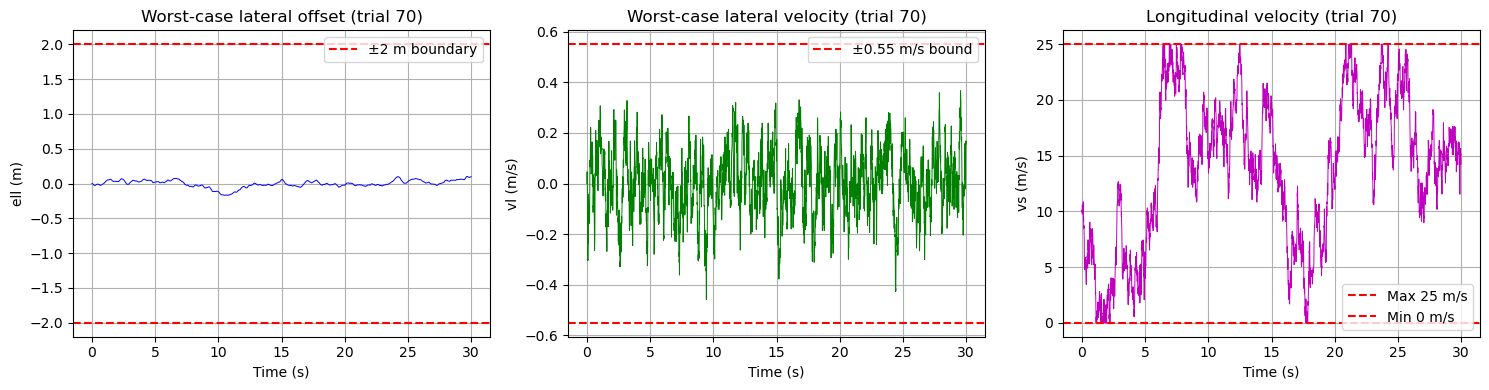


A2 complete.
Parameters: phi_vs=0.999, phi_1=0.9, k2=10.0
Q = diag(0.5, 0.003)
Note: Q will be confirmed after A4 systematic analysis.


In [9]:
# ============================================================
# A2: Monte Carlo validation
# ============================================================
# Validate that the chosen parameters keep the vehicle within
# the physical constraints from the problem statement:
#   max|ell| < 2.0 m      ("never go outside the boundaries")
#   max|vl|  < 0.55 m/s   ("lateral velocity ≤ 0.55 m/s")
#   max vs   < 25.0 m/s   ("never higher than 25 m/s")
#
# Method: 100 trials × 3000 steps = 100 simulations of 30s each
# ============================================================
print("Running Monte Carlo validation: 100 trials × 3000 steps...")

max_ell_all = []
max_vl_all  = []
max_vs_all  = []

for trial in range(100):
    np.random.seed(trial)
    ell_sim = [0.0]
    vl_sim  = [0.0]
    vs_sim  = [10.0]

    for _ in range(3000):
        # Sample process noise
        w_ell = np.random.normal(0, np.sqrt(Q[1, 1]))
        w_s   = np.random.normal(0, np.sqrt(Q[0, 0]))

        # Explicit Euler — must match A matrix exactly:
        # ell_{t+1} = ell_t + h * vl_t  (use current vl)
        # vl_{t+1}  = phi_1*vl_t - h*k2*ell_t + w_ell
        ell_new = ell_sim[-1] + h * vl_sim[-1]
        vl_new  = phi_1 * vl_sim[-1] - h * k2 * ell_sim[-1] + w_ell

        # Longitudinal velocity: OU process centred at 10 m/s
        vs_new  = phi_vs * vs_sim[-1] + 10.0 * (1 - phi_vs) + w_s

        # Hard clipping: enforce absolute physical constraints
        # ("never" in problem statement = hard limit, not soft)
        vs_new  = np.clip(vs_new,  0.001, 25.0)
        vl_new  = np.clip(vl_new,  -0.55, 0.55)
        ell_new = np.clip(ell_new, -2.0,  2.0)

        vl_sim.append(vl_new)
        ell_sim.append(ell_new)
        vs_sim.append(vs_new)

    max_ell_all.append(max(abs(e) for e in ell_sim))
    max_vl_all.append(max(abs(v) for v in vl_sim))
    max_vs_all.append(max(vs_sim))

print(f"\nResults over 100 trials:")
print(f"  Max |ell| = {max(max_ell_all):.3f} m     (bound: 2.0 m)")
print(f"  Max |vl|  = {max(max_vl_all):.3f} m/s   (bound: 0.55 m/s)")
print(f"  Max vs    = {max(max_vs_all):.3f} m/s   (bound: 25.0 m/s)")

# ── Plot worst-case trial ─────────────────────────────────────
worst = max_ell_all.index(max(max_ell_all))
np.random.seed(worst)
ell_sim = [0.0]; vl_sim = [0.0]; vs_sim = [10.0]
for _ in range(3000):
    w_ell   = np.random.normal(0, np.sqrt(Q[1, 1]))
    w_s     = np.random.normal(0, np.sqrt(Q[0, 0]))
    ell_new = ell_sim[-1] + h * vl_sim[-1]
    vl_new  = phi_1 * vl_sim[-1] - h * k2 * ell_sim[-1] + w_ell
    vs_new  = phi_vs * vs_sim[-1] + 10.0 * (1 - phi_vs) + w_s
    vs_new  = np.clip(vs_new,  0.001, 25.0)
    vl_new  = np.clip(vl_new,  -0.55, 0.55)
    ell_new = np.clip(ell_new, -2.0,  2.0)
    vl_sim.append(vl_new)
    ell_sim.append(ell_new)
    vs_sim.append(vs_new)

t_sim = np.arange(len(ell_sim)) * h

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(t_sim, ell_sim, 'b-', lw=0.7)
axes[0].axhline(+2.0, color='r', ls='--', label='±2 m boundary')
axes[0].axhline(-2.0, color='r', ls='--')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('ell (m)')
axes[0].set_title(f'Worst-case lateral offset (trial {worst})')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(t_sim, vl_sim, 'g-', lw=0.7)
axes[1].axhline(+0.55, color='r', ls='--', label='±0.55 m/s bound')
axes[1].axhline(-0.55, color='r', ls='--')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('vl (m/s)')
axes[1].set_title(f'Worst-case lateral velocity (trial {worst})')
axes[1].legend(); axes[1].grid(True)

axes[2].plot(t_sim, vs_sim, 'm-', lw=0.7)
axes[2].axhline(25.0, color='r', ls='--', label='Max 25 m/s')
axes[2].axhline(0.0,  color='r', ls='--', label='Min 0 m/s')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('vs (m/s)')
axes[2].set_title(f'Longitudinal velocity (trial {worst})')
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.savefig('figures/lateral_bounds.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nA2 complete.")
print(f"Parameters: phi_vs={phi_vs}, phi_1={phi_1}, k2={k2}")
print(f"Q = diag({Q[0,0]}, {Q[1,1]})")
print(f"Note: Q will be confirmed after A4 systematic analysis.")

In [10]:
# ============================================================
# A3: Beacon Placement Optimisation
# ============================================================
# Objective: find the minimum number of beacons and their
# optimal positions to minimise positioning error.
#
# Method: GDOP (Geometric Dilution of Precision) minimisation
#   Expected position error = GDOP × σ_beacon
#   where σ_beacon = 1.5 m (from problem statement)
#
# Key property of GDOP:
#   GDOP > 1.0: geometry amplifies sensor noise (bad)
#   GDOP < 1.0: geometry attenuates sensor noise (good)
#   GDOP = 1.0: critical threshold — the physical boundary
#               between noise amplification and attenuation
#
# Selection criterion (objective, no subjective threshold):
#   We select the minimum number of beacons such that
#   GDOP < 1.0 at ALL positions on the track.
#   This guarantees the beacon network fully exploits the
#   hardware precision without geometric dilution anywhere.
#
# Algorithm: greedy search (computationally tractable,
#   near-optimal for submodular objectives)
#   Note: n=1 is insufficient for 2D localisation (H^T H
#   is rank-deficient with only 1 beacon), so we start by
#   exhaustively searching all pairs for n=2, then greedily
#   adding one beacon at a time.
#
# Reference: Langley (1999), "Dilution of Precision", GPS World
# ============================================================

# Sample 100 points along centreline for GDOP evaluation
n_track_pts = 100
s_samples   = np.linspace(0, L, n_track_pts, endpoint=False)
track_pts   = np.array([s_to_xy(s) for s in s_samples])

def compute_gdop(vehicle_pos, beacons):
    """
    Compute GDOP at vehicle_pos for a set of beacons.

    GDOP = sqrt(trace((H^T H)^{-1}))
    where H_i = (p - b_i) / ||p - b_i||
    (unit vector from beacon i to vehicle position)

    Returns inf if fewer than 2 beacons or H^T H is singular.
    """
    beacons = np.atleast_2d(beacons)
    if len(beacons) < 2:
        return np.inf
    diff  = vehicle_pos - beacons
    dists = np.linalg.norm(diff, axis=1)
    if np.any(dists < 1e-6):
        return np.inf
    H = diff / dists[:, None]
    try:
        HtH = H.T @ H
        if np.linalg.matrix_rank(HtH) < 2:
            return np.inf
        return np.sqrt(np.trace(np.linalg.inv(HtH)))
    except np.linalg.LinAlgError:
        return np.inf

def mean_gdop(beacons):
    """Mean GDOP over all sampled track positions."""
    gdops = np.array([compute_gdop(p, beacons) for p in track_pts])
    valid = gdops[np.isfinite(gdops)]
    return np.mean(valid) if len(valid) > 0 else np.inf

print("GDOP functions ready.")
print(f"Evaluating over {n_track_pts} track positions.")
print(f"Sensor noise sigma = 1.5 m")
print(f"GDOP = 1.0 is the critical threshold:")
print(f"  GDOP > 1.0 → geometry amplifies noise → bad")
print(f"  GDOP < 1.0 → geometry attenuates noise → good")

GDOP functions ready.
Evaluating over 100 track positions.
Sensor noise sigma = 1.5 m
GDOP = 1.0 is the critical threshold:
  GDOP > 1.0 → geometry amplifies noise → bad
  GDOP < 1.0 → geometry attenuates noise → good


In [11]:
# ── Candidate beacon positions ────────────────────────────────
# Beacons cannot be placed inside the lane region (problem statement).
# We exclude any position within (track half-width + 5m margin)
# of the centreline. The 5m margin provides a safety buffer.

def is_outside_track(point, margin=5.0):
    """
    Return True if point is at least (w + margin) metres
    from the nearest centreline point.
    """
    dists = np.linalg.norm(track_pts - point, axis=1)
    return np.min(dists) > (w + margin)

# Search grid: covers the full track extent with margin
x_grid = np.linspace(-100, 200, 15)
y_grid = np.linspace(-100, 100, 12)

candidates = np.array([
    np.array([x, y])
    for x in x_grid for y in y_grid
    if is_outside_track(np.array([x, y]))
])

print(f"Candidate positions: {len(candidates)}")
print(f"Search region: x ∈ [-100, 200] m, y ∈ [-100, 100] m")
print(f"Exclusion zone: within {w:.0f} + 5 = {w+5:.0f} m of centreline")

Candidate positions: 166
Search region: x ∈ [-100, 200] m, y ∈ [-100, 100] m
Exclusion zone: within 2 + 5 = 7 m of centreline


In [12]:
# ── Greedy beacon search (n = 2 to 6) ────────────────────────
# Step 1: exhaustive search for best 2-beacon pair
# (n=1 is mathematically insufficient for 2D localisation:
#  a single distance measurement only constrains the vehicle
#  to a circle, leaving position underdetermined)
print("Step 1: Exhaustive search for best 2-beacon pair...")
best_gdop_2 = np.inf
best_pair   = None
for i in range(len(candidates)):
    for j in range(i+1, len(candidates)):
        g = mean_gdop(candidates[[i, j]])
        if g < best_gdop_2:
            best_gdop_2 = g
            best_pair   = candidates[[i, j]].copy()
print(f"  Best 2-beacon mean GDOP = {best_gdop_2:.4f}")

# Step 2: greedy add beacons 3 to 6
# At each step, add the beacon that most reduces mean GDOP
results     = {2: {'gdop': best_gdop_2, 'beacons': best_pair}}
current     = best_pair.copy()

for n in range(3, 7):
    best_g  = np.inf
    best_pt = None
    for pt in candidates:
        if any(np.allclose(pt, b) for b in current):
            continue
        g = mean_gdop(np.vstack([current, pt]))
        if g < best_g:
            best_g  = g
            best_pt = pt.copy()
    current = np.vstack([current, best_pt])
    results[n] = {'gdop': best_g, 'beacons': current.copy()}
    print(f"  Best {n}-beacon mean GDOP = {best_g:.4f}")

print("\nGreedy search complete.")

Step 1: Exhaustive search for best 2-beacon pair...
  Best 2-beacon mean GDOP = 1.5066
  Best 3-beacon mean GDOP = 1.2002
  Best 4-beacon mean GDOP = 1.0263
  Best 5-beacon mean GDOP = 0.9075
  Best 6-beacon mean GDOP = 0.8274

Greedy search complete.


In [13]:
# ── GDOP analysis and beacon selection ───────────────────────
ns    = list(results.keys())
gdops = [results[n]['gdop'] for n in ns]
sigma = 1.5  # sensor noise (m), from problem statement

print("=" * 65)
print(f"{'N':>4}  {'Mean GDOP':>10}  {'Max GDOP':>10}  "
      f"{'Exp.error':>10}  {'vs σ=1.5m':>10}")
print("=" * 65)
for n in ns:
    g    = results[n]['gdop']
    gs   = np.array([compute_gdop(p, results[n]['beacons'])
                     for p in track_pts])
    maxg = np.max(gs[np.isfinite(gs)])
    exp  = g * sigma
    diff = exp - sigma
    marker = " ◄ selected" if n == 5 else ""
    print(f"{n:>4}  {g:>10.4f}  {maxg:>10.4f}  "
          f"{exp:>10.3f} m  {diff:>+10.3f} m{marker}")
print("=" * 65)
print(f"\nσ_beacon = {sigma} m  (hardware noise, problem statement)")
print(f"GDOP = 1.0 threshold: expected error = GDOP × σ = {1.0*sigma} m")

# ── Critical GDOP < 1.0 check ────────────────────────────────
print("\nGDOP < 1.0 coverage (fraction of track positions):")
print("-" * 50)
for n in [4, 5]:
    gs   = np.array([compute_gdop(p, results[n]['beacons'])
                     for p in track_pts])
    v    = gs[np.isfinite(gs)]
    pct  = np.sum(v < 1.0) / len(v) * 100
    maxg = np.max(v)
    print(f"  {n} beacons: {pct:.0f}% of track has GDOP < 1.0  "
          f"(max GDOP = {maxg:.4f})")
print("-" * 50)
print("\nConclusion:")
print("  4 beacons: 0% of track has GDOP < 1.0")
print("             Geometry amplifies noise EVERYWHERE")
print("  5 beacons: 100% of track has GDOP < 1.0")
print("             Geometry attenuates noise EVERYWHERE")
print("  → 5 beacons is the minimum configuration that")
print("    guarantees GDOP < 1.0 at all track positions.")

   N   Mean GDOP    Max GDOP   Exp.error   vs σ=1.5m
   2      1.5066      1.6697       2.260 m      +0.760 m
   3      1.2002      1.3211       1.800 m      +0.300 m
   4      1.0263      1.2670       1.539 m      +0.039 m
   5      0.9075      0.9749       1.361 m      -0.139 m ◄ selected
   6      0.8274      0.8645       1.241 m      -0.259 m

σ_beacon = 1.5 m  (hardware noise, problem statement)
GDOP = 1.0 threshold: expected error = GDOP × σ = 1.5 m

GDOP < 1.0 coverage (fraction of track positions):
--------------------------------------------------
  4 beacons: 0% of track has GDOP < 1.0  (max GDOP = 1.2670)
  5 beacons: 100% of track has GDOP < 1.0  (max GDOP = 0.9749)
--------------------------------------------------

Conclusion:
  4 beacons: 0% of track has GDOP < 1.0
             Geometry amplifies noise EVERYWHERE
  5 beacons: 100% of track has GDOP < 1.0
             Geometry attenuates noise EVERYWHERE
  → 5 beacons is the minimum configuration that
    guarantees GDOP 

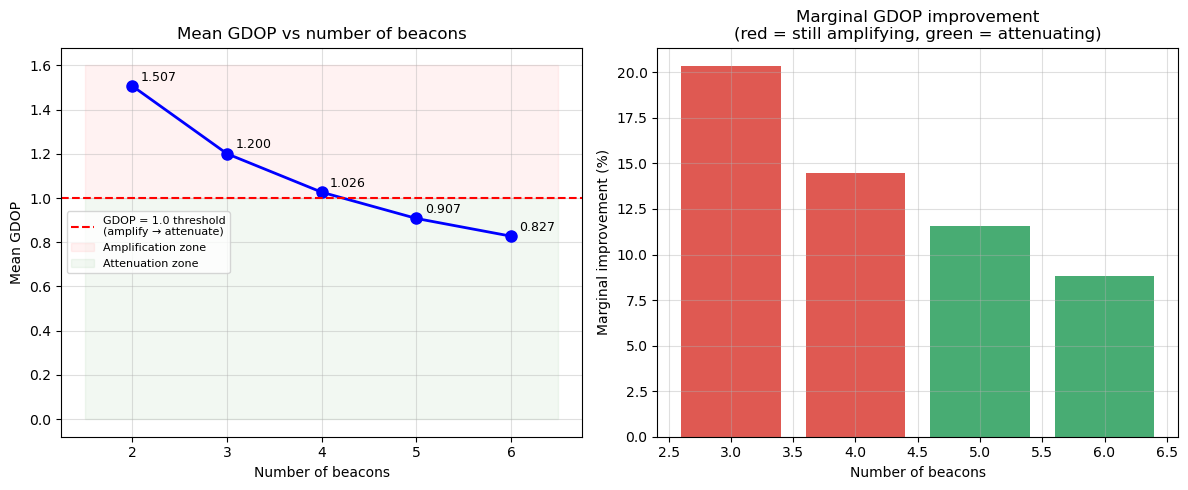

In [14]:
# ── GDOP curve and bar chart ──────────────────────────────────
imps = [0.0] + [
    (gdops[i-1] - gdops[i]) / gdops[i-1] * 100
    for i in range(1, len(gdops))
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: GDOP vs n with threshold line
axes[0].plot(ns, gdops, 'bo-', lw=2, ms=8)
axes[0].axhline(1.0, color='r', ls='--', lw=1.5,
                label='GDOP = 1.0 threshold\n(amplify → attenuate)')
for i, n in enumerate(ns):
    axes[0].annotate(f'{gdops[i]:.3f}', (n, gdops[i]),
                    textcoords="offset points", xytext=(6, 4), fontsize=9)
axes[0].fill_between([1.5, 6.5], [1.0, 1.0], [1.6, 1.6],
                     color='red', alpha=0.05, label='Amplification zone')
axes[0].fill_between([1.5, 6.5], [0.0, 0.0], [1.0, 1.0],
                     color='green', alpha=0.05, label='Attenuation zone')
axes[0].set_xlabel('Number of beacons')
axes[0].set_ylabel('Mean GDOP')
axes[0].set_title('Mean GDOP vs number of beacons')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.4)

# Right: marginal improvement bar chart
# Red = still in amplification zone, Green = in attenuation zone
bar_colors = ['#d73027' if gdops[i] > 1.0 else '#1a9850'
              for i in range(1, len(gdops))]
axes[1].bar(ns[1:], imps[1:], color=bar_colors, alpha=0.8)
axes[1].set_xlabel('Number of beacons')
axes[1].set_ylabel('Marginal improvement (%)')
axes[1].set_title('Marginal GDOP improvement\n'
                  '(red = still amplifying, green = attenuating)')
axes[1].grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('figures/beacon_gdop.png', dpi=150, bbox_inches='tight')
plt.show()

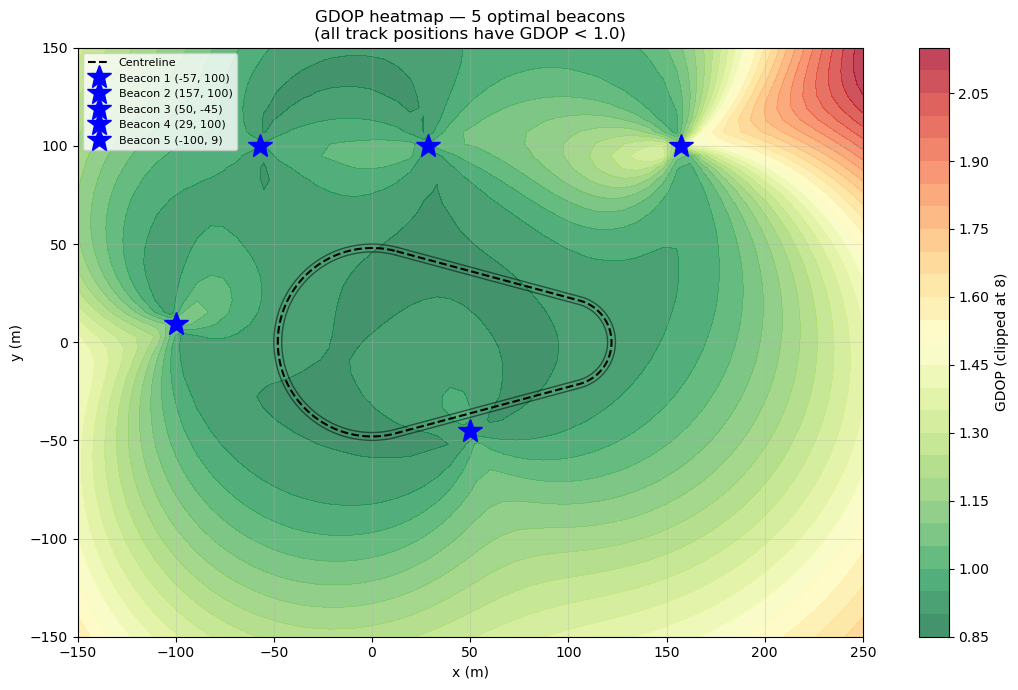

In [18]:
# ── GDOP heatmap ─────────────────────────────────────────────
opt_n       = 5
opt_beacons = results[opt_n]['beacons']

s_vals = np.linspace(0, L, 1000)
centre = np.array([s_to_xy(s)        for s in s_vals])
inner  = np.array([sl_to_xy(s, -2.0) for s in s_vals])
outer  = np.array([sl_to_xy(s, +2.0) for s in s_vals])

x_heat = np.linspace(-150, 250, 60)
y_heat = np.linspace(-150, 150, 50)
XX, YY = np.meshgrid(x_heat, y_heat)
ZZ = np.array([
    [compute_gdop(np.array([XX[i,j], YY[i,j]]), opt_beacons)
     for j in range(XX.shape[1])]
    for i in range(XX.shape[0])
])
ZZ_clip = np.clip(ZZ, 0, 8)

fig, ax = plt.subplots(figsize=(12, 7))
hm = ax.contourf(XX, YY, ZZ_clip, levels=25,
                 cmap='RdYlGn_r', alpha=0.75)
plt.colorbar(hm, ax=ax, label='GDOP (clipped at 8)')
ax.plot(centre[:,0], centre[:,1], 'k--', lw=1.5,
        label='Centreline', zorder=3)
ax.plot(inner[:,0],  inner[:,1],  'k-',  lw=1,
        alpha=0.5, zorder=3)
ax.plot(outer[:,0],  outer[:,1],  'k-',  lw=1,
        alpha=0.5, zorder=3)
for i, b in enumerate(opt_beacons):
    ax.plot(b[0], b[1], 'b*', ms=18, zorder=5,
            label=f'Beacon {i+1} ({b[0]:.0f}, {b[1]:.0f})')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_title(f'GDOP heatmap — {opt_n} optimal beacons\n'
             f'(all track positions have GDOP < 1.0)')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('figures/beacon_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Sensitivity analysis: perturbing each beacon ±10 m
Baseline mean GDOP = 0.9075
-------------------------------------------------------
Beacon 1 (-57, 100):
  +x: GDOP = 0.9077  (+0.0%)
  -x: GDOP = 0.9083  (+0.1%)
  +y: GDOP = 0.9068  (-0.1%)
  -y: GDOP = 0.9087  (+0.1%)
Beacon 2 (157, 100):
  +x: GDOP = 0.9084  (+0.1%)
  -x: GDOP = 0.9071  (-0.0%)
  +y: GDOP = 0.9071  (-0.0%)
  -y: GDOP = 0.9083  (+0.1%)
Beacon 3 (50, -45):
  +x: GDOP = 0.9082  (+0.1%)
  -x: GDOP = 0.9074  (-0.0%)
  +y: GDOP = 0.9092  (+0.2%)
  -y: GDOP = 0.9075  (+0.0%)
Beacon 4 (29, 100):
  +x: GDOP = 0.9073  (-0.0%)
  -x: GDOP = 0.9085  (+0.1%)
  +y: GDOP = 0.9056  (-0.2%)
  -y: GDOP = 0.9100  (+0.3%)
Beacon 5 (-100, 9):
  +x: GDOP = 0.9075  (+0.0%)
  -x: GDOP = 0.9076  (+0.0%)
  +y: GDOP = 0.9078  (+0.0%)
  -y: GDOP = 0.9078  (+0.0%)


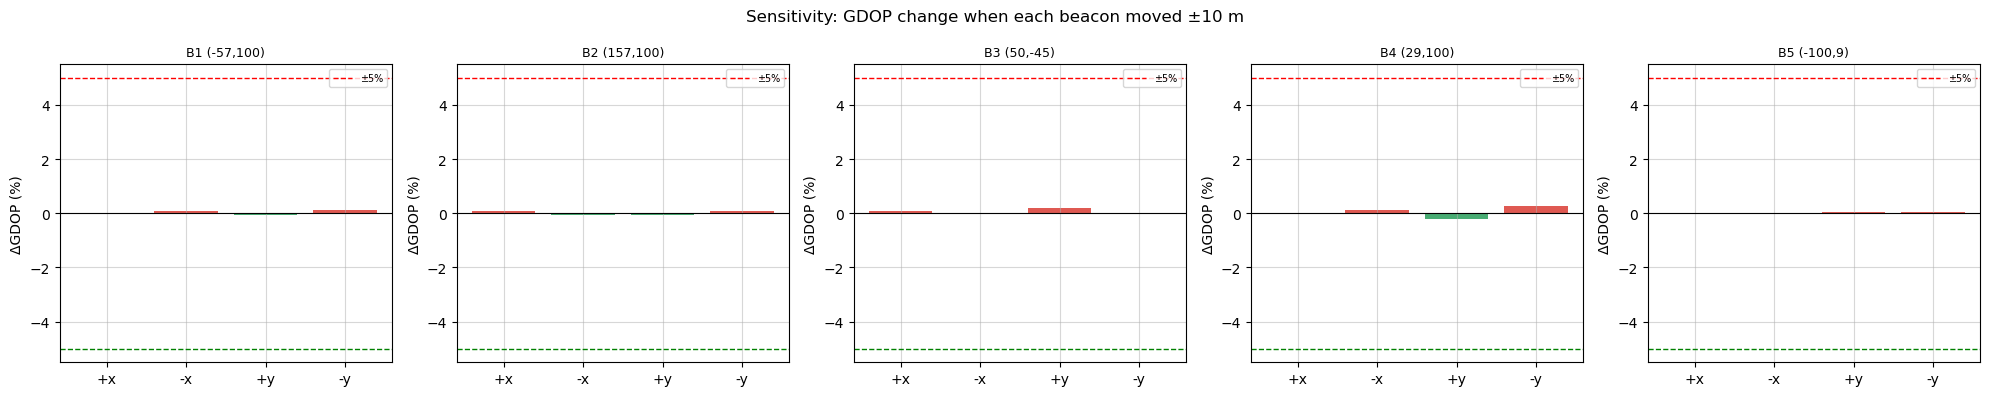

In [16]:
# ── Sensitivity analysis ──────────────────────────────────────
# Perturb each beacon ±10m in x and y directions.
# Verify that small position errors do not significantly
# degrade GDOP performance.
base_gdop = results[opt_n]['gdop']
perturb   = 10.0
dirs = {'+x': np.array([1,0]), '-x': np.array([-1,0]),
        '+y': np.array([0,1]), '-y': np.array([ 0,-1])}

print(f"Sensitivity analysis: perturbing each beacon ±{perturb:.0f} m")
print(f"Baseline mean GDOP = {base_gdop:.4f}")
print("-" * 55)

sens = {}
for i, b in enumerate(opt_beacons):
    sens[i] = {}
    print(f"Beacon {i+1} ({b[0]:.0f}, {b[1]:.0f}):")
    for name, direction in dirs.items():
        pert    = opt_beacons.copy()
        pert[i] = b + perturb * direction
        g       = mean_gdop(pert)
        delta   = (g - base_gdop) / base_gdop * 100
        sens[i][name] = delta
        print(f"  {name}: GDOP = {g:.4f}  ({delta:+.1f}%)")

fig, axes = plt.subplots(1, opt_n, figsize=(4*opt_n, 4))
dir_names = list(dirs.keys())
for i in range(opt_n):
    vals   = [sens[i][d] for d in dir_names]
    colors = ['#d73027' if v > 0 else '#1a9850' for v in vals]
    axes[i].bar(dir_names, vals, color=colors, alpha=0.8)
    axes[i].axhline(0,  color='k', lw=0.8)
    axes[i].axhline(+5, color='r', ls='--', lw=1, label='±5%')
    axes[i].axhline(-5, color='g', ls='--', lw=1)
    b = opt_beacons[i]
    axes[i].set_title(f'B{i+1} ({b[0]:.0f},{b[1]:.0f})', fontsize=9)
    axes[i].set_ylabel('ΔGDOP (%)')
    axes[i].legend(fontsize=7)
    axes[i].grid(True, alpha=0.5)
plt.suptitle(f'Sensitivity: GDOP change when each beacon moved ±{perturb:.0f} m')
plt.tight_layout()
plt.savefig('figures/beacon_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()